# Local Trend Model

$$\mu_{t+1} = \mu_t+\epsilon_t$$

$$y_t = \mu_t + \eta_t$$

where $\epsilon_t$ and  $\eta_t$ are two independent Gaussian noise variables with standard deviations $\sigma_{\epsilon}$ and $\sigma_{\eta}$

This model can  be used to analyze realized volatility of an asset price; 
$\mu_t$ represents the underlying log volatility of the asset price 

$y_t$ is the logarithm of realized volatility. The true log volatility is not directly observed but evolves over time according to a
random-walk model. 

$y_t$  is constructed from high-frequency transactions data and subjected to the influence of market microstructure noises.


# As State-Space Model

The same model can be interpreted as linear Gaussian state-space model

$\mu_t$ is state of the system at time t and cannot be directly observed.

Equation for $y_t$ is called observation equation with measurement error $\eta_t$ and provides link between observed variable $y_t$ and unobserved $\mu_t$.



In the following example filtering is demonstrated on intraday realized volatility of Alcoa stock 

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("aa-rv-20m.csv", header=None)
df.columns = ["volatility"]
dates = pd.bdate_range(start="2003-01-02", periods=340)
df["date"] = dates
df = df[["date", "volatility"]]
# Convert to numpy
y = df["volatility"].values
y_log = np.log(y)

In [23]:
from statsmodels.tsa.statespace.kalman_filter import KalmanFilter

kf = KalmanFilter(k_endog=1, k_states=1)
kf.bind(y_log.reshape(-1, 1))

# Observation: y_t = x_t + noise
kf['design'] = np.array([[1]])

# State: random walk
kf['transition'] = np.array([[1]])
kf['selection'] = np.array([[1]])

#later covariances can be estimated via MLE 
kf['obs_cov'] = np.array([[0.1]])   # measurement noise
kf['state_cov'] = np.array([[0.01]])  # state noise

# Initial condition
kf.initialize_known(np.array([y_log[0]]), np.array([[1]]))

In [24]:
res = kf.filter()

In [25]:
filtered_state = res.filtered_state[0]
filtered_var = res.filtered_state_cov[0,0,:]

In [26]:
#critical value for 95% confidence interval
z = 1.96

filtered_std = np.sqrt(filtered_var)
f_upper = filtered_state + z * filtered_std
f_lower = filtered_state - z * filtered_std

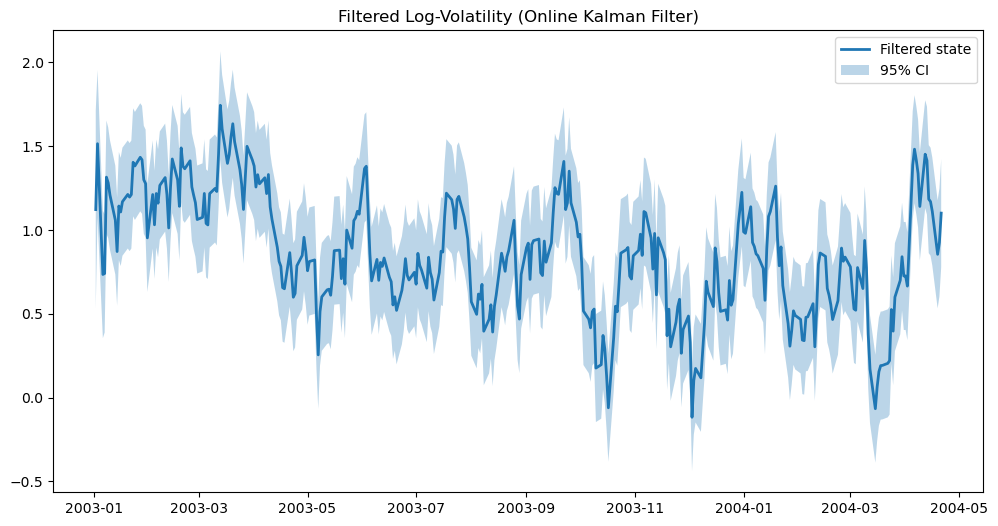

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(df["date"], filtered_state, label="Filtered state", linewidth=2)
plt.fill_between(df["date"], f_lower, f_upper, alpha=0.3, label="95% CI")

plt.title("Filtered Log-Volatility (Online Kalman Filter)")
plt.legend()
plt.show()

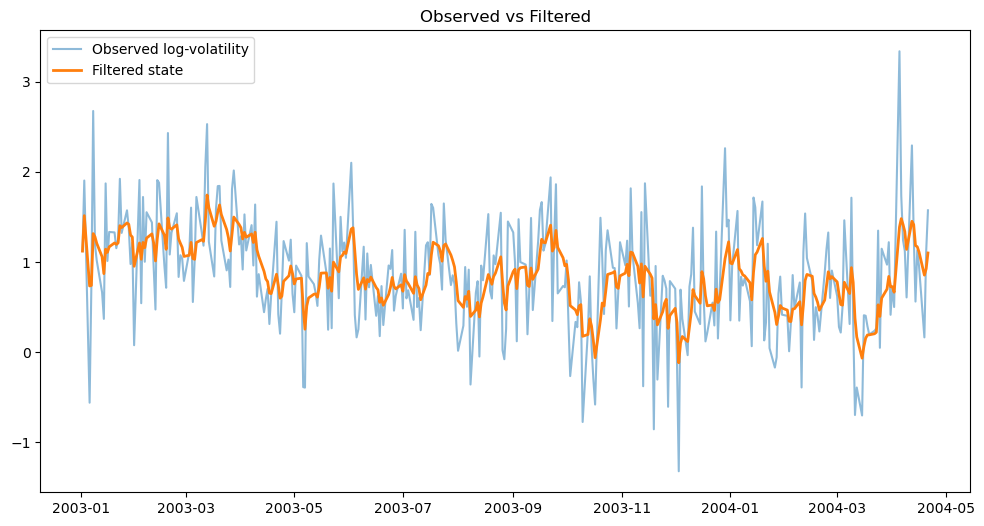

In [28]:
plt.figure(figsize=(12,6))

# Observed 
plt.plot(df["date"], y_log, label="Observed log-volatility", alpha=0.5)

# Filtered 
plt.plot(df["date"], filtered_state, label="Filtered state", linewidth=2)

plt.title("Observed vs Filtered")
plt.legend()
plt.show()